In [46]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
DATASET_PATH = "data"
SR = 16000
N_MFCC = 40
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SR)

    # MFCCs
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=512,
        hop_length=160
    )

    # Deltas
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    features = np.vstack([mfcc, delta, delta2])

    # Statistical pooling
    feature_vector = np.hstack([
        np.mean(features, axis=1),
        np.std(features, axis=1)
    ])

    return feature_vector


In [47]:
import os
import librosa
import numpy as np

DATASET_PATH = "data/raw"

CLASSES = [
    "belly_pain",
    "burping",
    "discomfort",
    "hungry",
    "tired"
]


In [48]:
X = []
y = []

for label, class_name in enumerate(CLASSES):
    class_folder = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_folder):
        if file.endswith(".wav"):
            filepath = os.path.join(class_folder, file)

            features = extract_features(filepath)

            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  
print("y shape:", y.shape)  

X shape: (457, 240)
y shape: (457,)


In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [51]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [52]:
tsne = TSNE(
    n_components=2,
    perplexity=10,        # small dataset
    learning_rate=200,
   max_iter=5000,

    metric="cosine",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)


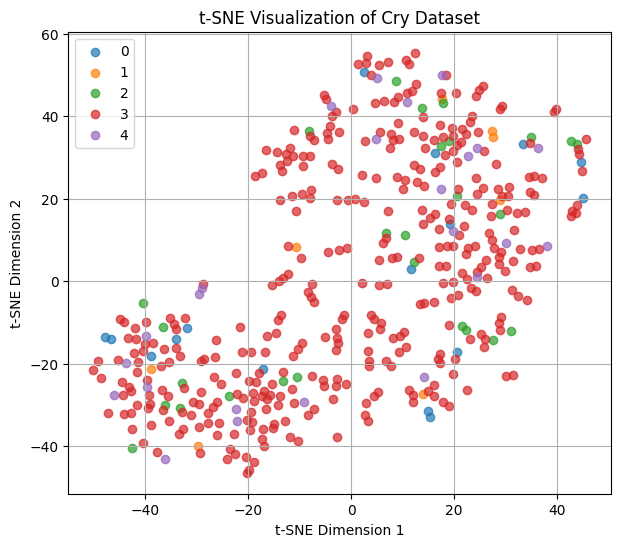

In [53]:
plt.figure(figsize=(7, 6))

for label in np.unique(y_encoded):
    idx = y_encoded == label
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=le.inverse_transform([label])[0],
        alpha=0.7
    )

plt.legend()
plt.title("t-SNE Visualization of Cry Dataset")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()


In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=4)
X_lda = lda.fit_transform(X_scaled, y_encoded)

X_tsne = TSNE(perplexity=10,max_iter=5000).fit_transform(X_lda)


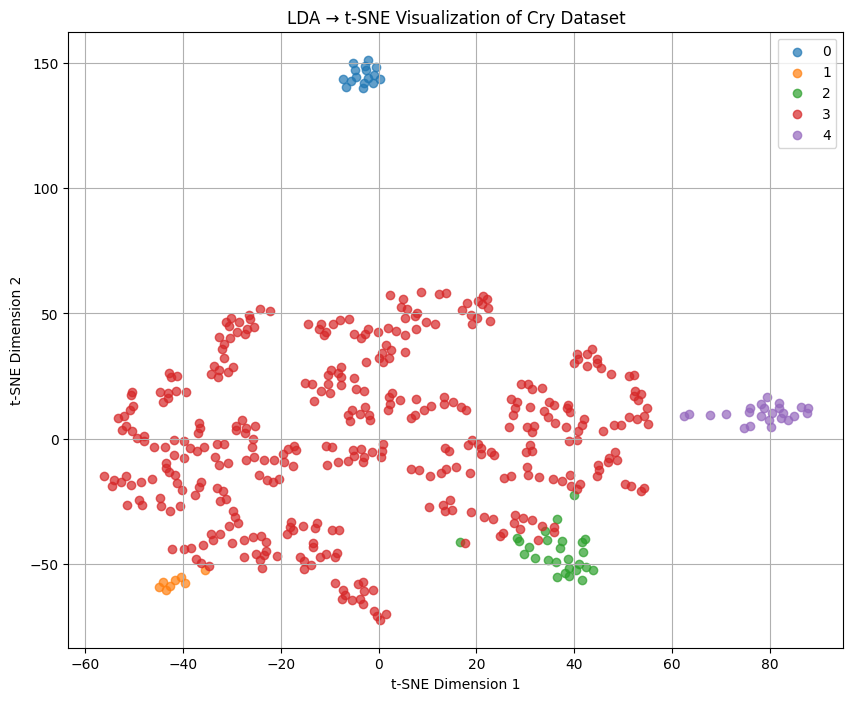

In [60]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

for label in np.unique(y_encoded):
    idx = y_encoded == label
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        alpha=0.7,
        label=le.inverse_transform([label])[0]
    )

plt.title("LDA → t-SNE Visualization of Cry Dataset")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True)
plt.show()
